# Task 5 — Deep Learning Fundamentals
**Course:** Machine Learning & Deep Learning  
**Points:** 10/60  
**School of Artificial Intelligence and Data Science**

---

## Overview
We implement and analyze core deep learning concepts using **TensorFlow/Keras**:
- Multi-Layer Perceptron (MLP) with Dropout & Batch Normalization
- Optimizer comparison: SGD vs Adam vs RMSProp
- Conceptual questions on vanishing gradients, BN, and learning rate

## Step 0 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42)
np.random.seed(42)
sns.set_theme(style='whitegrid')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

I0000 00:00:1778441803.315882  149833 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778441803.400636  149833 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778441805.534660  149833 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
GPU available: False


E0000 00:00:1778441806.067266  149833 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778441806.100409  149833 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Step 1 — Data Preparation

In [2]:
def prepare_data():
    """Load Wine dataset, scale features, one-hot encode labels. Split 70/15/15."""
    wine = load_wine()
    X = wine.data.astype(np.float32)
    y = wine.target

    # Scale
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # One-hot encode
    y_ohe = tf.keras.utils.to_categorical(y, num_classes=3)

    # Split 70 / 15 / 15
    X_train, X_temp, y_train, y_temp = train_test_split(X, y_ohe, test_size=0.30, random_state=42, stratify=y)
    X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

    print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
    print(f'Features: {X_train.shape[1]}, Classes: 3')
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = prepare_data()
INPUT_DIM = X_train.shape[1]
N_CLASSES  = 3

Train: (124, 13)  Val: (27, 13)  Test: (27, 13)
Features: 13, Classes: 3


## 6.1 MLP Implementation

### Architecture
```
Input (13) → Dense(256, ReLU) → BN → Dropout(0.3)
           → Dense(128, ReLU) → BN → Dropout(0.3)
           → Dense(64, ReLU)  → BN → Dropout(0.2)
           → Dense(3, Softmax)
```

In [3]:
def build_mlp(input_dim, n_classes, activation='relu', dropout_rates=(0.3, 0.3, 0.2),
              l2_reg=1e-4, name='MLP'):
    """
    Build MLP with 3 hidden layers, BatchNormalization, and Dropout.
    
    Parameters
    ----------
    input_dim    : number of input features
    n_classes    : number of output classes
    activation   : activation for hidden layers
    dropout_rates: tuple of dropout rates per hidden layer
    l2_reg       : L2 regularization coefficient
    name         : model name
    """
    reg = regularizers.l2(l2_reg)
    
    model = keras.Sequential([
        layers.Input(shape=(input_dim,), name='input'),

        # Hidden layer 1
        layers.Dense(256, kernel_regularizer=reg, name='dense_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Activation(activation, name='act_1'),
        layers.Dropout(dropout_rates[0], name='drop_1'),

        # Hidden layer 2
        layers.Dense(128, kernel_regularizer=reg, name='dense_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Activation(activation, name='act_2'),
        layers.Dropout(dropout_rates[1], name='drop_2'),

        # Hidden layer 3
        layers.Dense(64, kernel_regularizer=reg, name='dense_3'),
        layers.BatchNormalization(name='bn_3'),
        layers.Activation(activation, name='act_3'),
        layers.Dropout(dropout_rates[2], name='drop_3'),

        # Output
        layers.Dense(n_classes, activation='softmax', name='output'),
    ], name=name)
    
    return model

# Build and show architecture
model_relu = build_mlp(INPUT_DIM, N_CLASSES, activation='relu', name='MLP_ReLU')
model_relu.summary()

# Count parameters
total_params = model_relu.count_params()
print(f'\nTotal parameters: {total_params:,}')

Model: "MLP_ReLU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,723 (182.51 KB)

 Trainable params: 45,827 (179.01 KB)

 Non-trainable params: 896 (3.50 KB)


Total parameters: 46,723


Training MLP with ReLU activation + Adam optimizer...
Training MLP with Tanh activation + Adam optimizer...


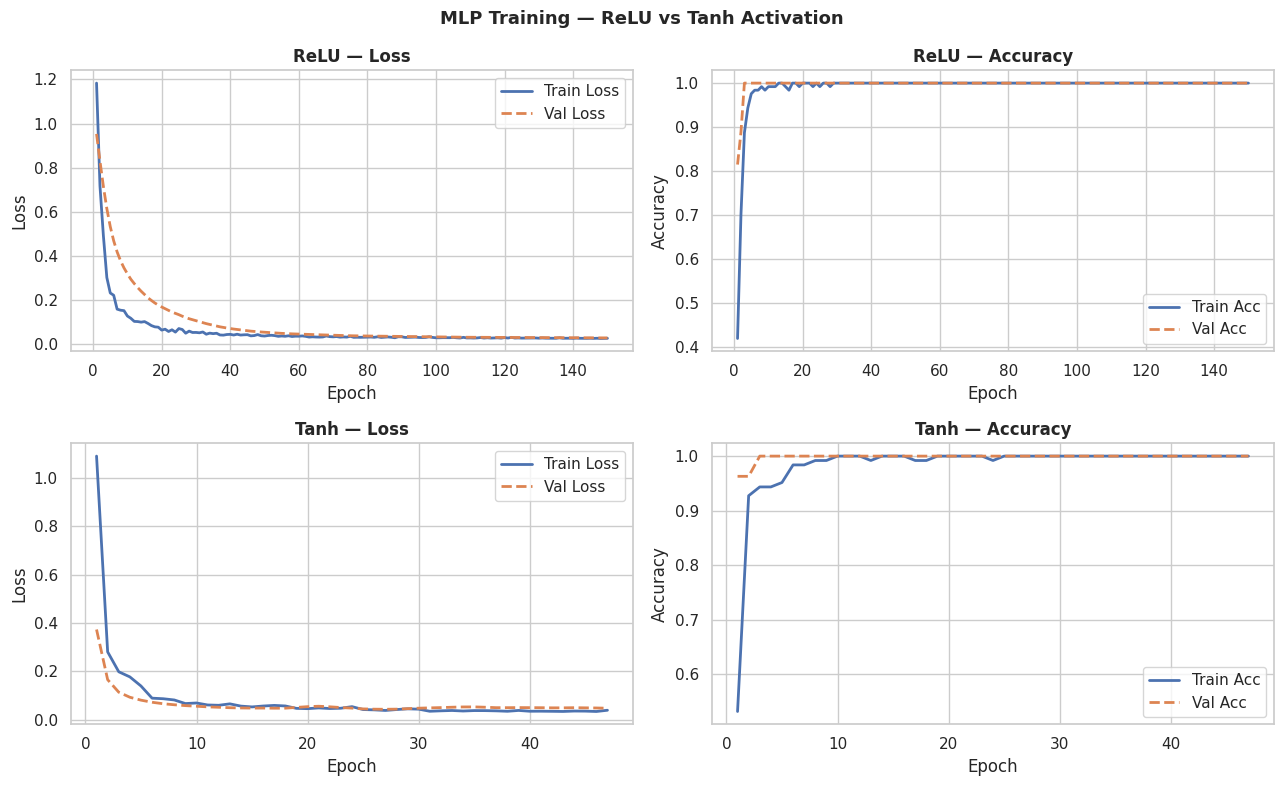

ReLU — Test Loss: 0.0626  Test Acc: 1.0000
Tanh — Test Loss: 0.0988  Test Acc: 1.0000


In [4]:
def train_mlp(model, optimizer, X_train, y_train, X_val, y_val, epochs=150, batch_size=32):
    """
    Compile and train MLP. Returns history object.
    Uses EarlyStopping and ReduceLROnPlateau callbacks.
    """
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    ]
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )
    
    return history

def plot_history(history, title, ax_loss, ax_acc):
    """Plot training and validation loss/accuracy curves."""
    epochs = range(1, len(history.history['loss'])+1)
    ax_loss.plot(epochs, history.history['loss'],     label='Train Loss', lw=2)
    ax_loss.plot(epochs, history.history['val_loss'], label='Val Loss',   lw=2, linestyle='--')
    ax_loss.set_title(f'{title} — Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    
    ax_acc.plot(epochs, history.history['accuracy'],     label='Train Acc', lw=2)
    ax_acc.plot(epochs, history.history['val_accuracy'], label='Val Acc',   lw=2, linestyle='--')
    ax_acc.set_title(f'{title} — Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

# Train with Adam (main experiment)
print('Training MLP with ReLU activation + Adam optimizer...')
model_relu = build_mlp(INPUT_DIM, N_CLASSES, activation='relu', name='MLP_ReLU')
history_relu = train_mlp(model_relu, keras.optimizers.Adam(1e-3),
                         X_train, y_train, X_val, y_val)

print('Training MLP with Tanh activation + Adam optimizer...')
model_tanh = build_mlp(INPUT_DIM, N_CLASSES, activation='tanh', name='MLP_Tanh')
history_tanh = train_mlp(model_tanh, keras.optimizers.Adam(1e-3),
                         X_train, y_train, X_val, y_val)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_history(history_relu, 'ReLU', axes[0,0], axes[0,1])
plot_history(history_tanh, 'Tanh', axes[1,0], axes[1,1])
plt.suptitle('MLP Training — ReLU vs Tanh Activation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('T4_activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation
for name, model in [('ReLU', model_relu), ('Tanh', model_tanh)]:
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'{name} — Test Loss: {loss:.4f}  Test Acc: {acc:.4f}')

## 6.2 Optimizer Study: SGD vs Adam vs RMSProp

Training with SGD (lr=0.01, momentum=0.9)...
  → Test Acc: 0.9630  Epochs: 200
Training with Adam (lr=0.001)...
  → Test Acc: 0.9630  Epochs: 200
Training with RMSProp (lr=0.001)...
  → Test Acc: 1.0000  Epochs: 174


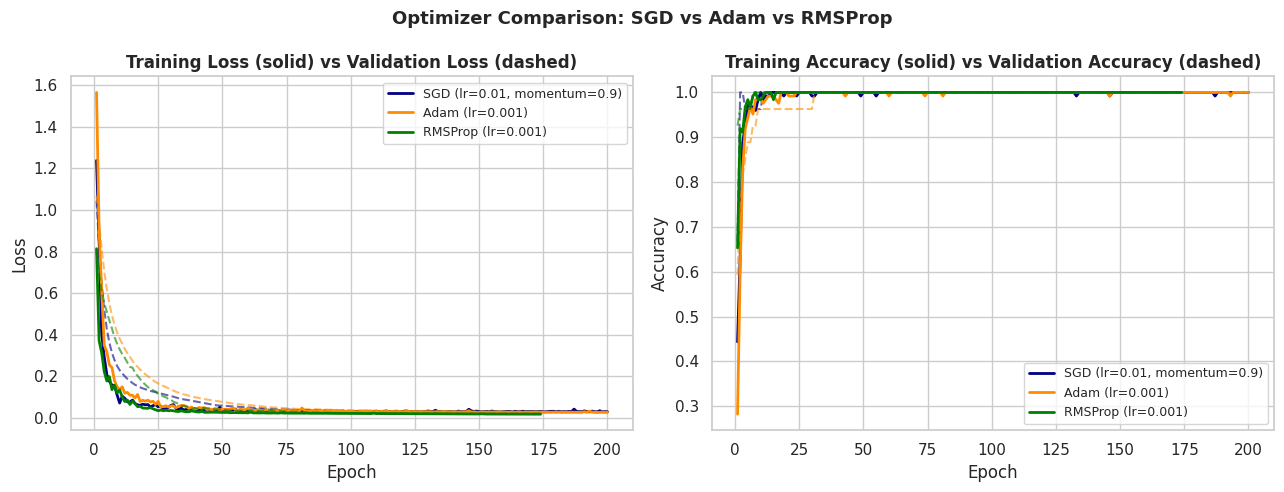


Optimizer Summary:
                             test_loss  test_acc  epochs_trained
SGD (lr=0.01, momentum=0.9)   0.079113  0.962963           200.0
Adam (lr=0.001)               0.081850  0.962963           200.0
RMSProp (lr=0.001)            0.041623  1.000000           174.0


In [5]:
optimizers_config = {
    'SGD (lr=0.01, momentum=0.9)': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam (lr=0.001)':             keras.optimizers.Adam(learning_rate=0.001),
    'RMSProp (lr=0.001)':          keras.optimizers.RMSprop(learning_rate=0.001),
}

optimizer_histories = {}
optimizer_metrics   = {}

for opt_name, optimizer in optimizers_config.items():
    print(f'Training with {opt_name}...')
    m = build_mlp(INPUT_DIM, N_CLASSES, activation='relu', name=f'MLP_{opt_name.split("(")[0].strip()}')
    h = train_mlp(m, optimizer, X_train, y_train, X_val, y_val, epochs=200)
    optimizer_histories[opt_name] = h
    loss, acc = m.evaluate(X_test, y_test, verbose=0)
    optimizer_metrics[opt_name] = {'test_loss': loss, 'test_acc': acc,
                                   'epochs_trained': len(h.history['loss'])}
    print(f'  → Test Acc: {acc:.4f}  Epochs: {len(h.history["loss"])}')

# Plot all loss curves together
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['navy', 'darkorange', 'green']

for (name, history), color in zip(optimizer_histories.items(), colors):
    epochs = range(1, len(history.history['loss'])+1)
    axes[0].plot(epochs, history.history['loss'],     color=color, lw=2,  label=name)
    axes[0].plot(epochs, history.history['val_loss'], color=color, lw=1.5, linestyle='--', alpha=0.6)
    axes[1].plot(epochs, history.history['accuracy'],     color=color, lw=2,  label=name)
    axes[1].plot(epochs, history.history['val_accuracy'], color=color, lw=1.5, linestyle='--', alpha=0.6)

axes[0].set_title('Training Loss (solid) vs Validation Loss (dashed)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9)

axes[1].set_title('Training Accuracy (solid) vs Validation Accuracy (dashed)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)

plt.suptitle('Optimizer Comparison: SGD vs Adam vs RMSProp', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/T4_optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\nOptimizer Summary:')
df_opt = pd.DataFrame(optimizer_metrics).T
print(df_opt.to_string())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         8
     class_1       0.83      1.00      0.91        10
     class_2       1.00      0.78      0.88         9

    accuracy                           0.93        27
   macro avg       0.94      0.93      0.93        27
weighted avg       0.94      0.93      0.92        27



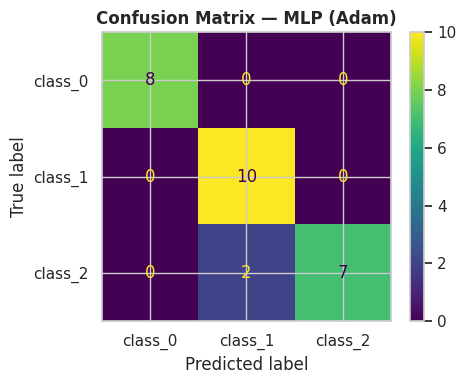

In [6]:
# Final confusion matrix for best model (Adam)
best_model = list(optimizer_histories.keys())[1]  # Adam

# Rebuild and re-train best model for final evaluation
final_model = build_mlp(INPUT_DIM, N_CLASSES, activation='relu')
final_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                    loss='categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                epochs=150, batch_size=32, verbose=0,
                callbacks=[EarlyStopping(patience=20, restore_best_weights=True)])

y_pred_ohe  = final_model.predict(X_test)
y_pred_cls  = np.argmax(y_pred_ohe, axis=1)
y_true_cls  = np.argmax(y_test, axis=1)

print(classification_report(y_true_cls, y_pred_cls, target_names=load_wine().target_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_true_cls, y_pred_cls),
                       display_labels=load_wine().target_names).plot(ax=ax)
ax.set_title('Confusion Matrix — MLP (Adam)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/T4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Conceptual Questions

### Q1: Vanishing Gradient Problem

During backpropagation, gradients are computed via the chain rule:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial a_n} \cdot \prod_{k=2}^{n} \sigma'(z_k) \cdot w_k$$

With **sigmoid/tanh** activations, $\sigma'(z) \in (0, 0.25]$. In deep networks, this product approaches **zero exponentially** — early layers receive negligible gradient updates and fail to learn.

**Modern solutions:**
- **ReLU** activation: $f'(z) = 1$ for $z > 0$ — no gradient attenuation in the positive region
- **Batch Normalization:** Normalizes layer inputs, keeping activations in a healthy gradient range
- **Residual connections (ResNet):** Skip connections provide a direct gradient path: $\frac{\partial L}{\partial x} = \frac{\partial L}{\partial F+x} \cdot (\frac{\partial F}{\partial x} + 1)$ — the +1 prevents vanishing
- **Careful weight initialization** (He, Xavier/Glorot)

---

### Q2: Why does Batch Normalization Accelerate Training?

For a mini-batch $\mathcal{B} = \{x_1, ..., x_m\}$:

$$\mu_{\mathcal{B}} = \frac{1}{m}\sum_{i=1}^m x_i \qquad \sigma^2_{\mathcal{B}} = \frac{1}{m}\sum_{i=1}^m (x_i - \mu_{\mathcal{B}})^2$$

$$\hat{x}_i = \frac{x_i - \mu_{\mathcal{B}}}{\sqrt{\sigma^2_{\mathcal{B}} + \epsilon}} \qquad y_i = \gamma \hat{x}_i + \beta$$

where $\gamma$ and $\beta$ are **learnable** scale and shift parameters.

**Benefits:**
1. Reduces **internal covariate shift** — each layer receives stable input distributions
2. Allows higher learning rates without divergence
3. Acts as a regularizer — reduces need for Dropout in some architectures
4. Smooths the loss landscape — larger gradient steps are safe

---

### Q3: Role of Learning Rate

The learning rate $\eta$ controls the step size in parameter space:

$$\theta_{t+1} = \theta_t - \eta \nabla_{\theta} L(\theta_t)$$

| Learning Rate | Effect |
|---|---|
| **Too high** | Overshoots minima → oscillation or divergence; training loss increases or NaN |
| **Too low** | Extremely slow convergence; may get stuck in local minima or saddle points |
| **Just right** | Stable, efficient convergence to good local minimum |

**Strategies:**
- **Learning rate schedules:** Step decay, cosine annealing, exponential decay
- **Warm-up:** Start low, increase, then decay (used in Transformers)
- **Adaptive optimizers (Adam, RMSProp):** Per-parameter learning rates, reducing sensitivity to initial choice
- **Learning rate finder:** Train briefly with linearly increasing LR; pick value just before loss spikes

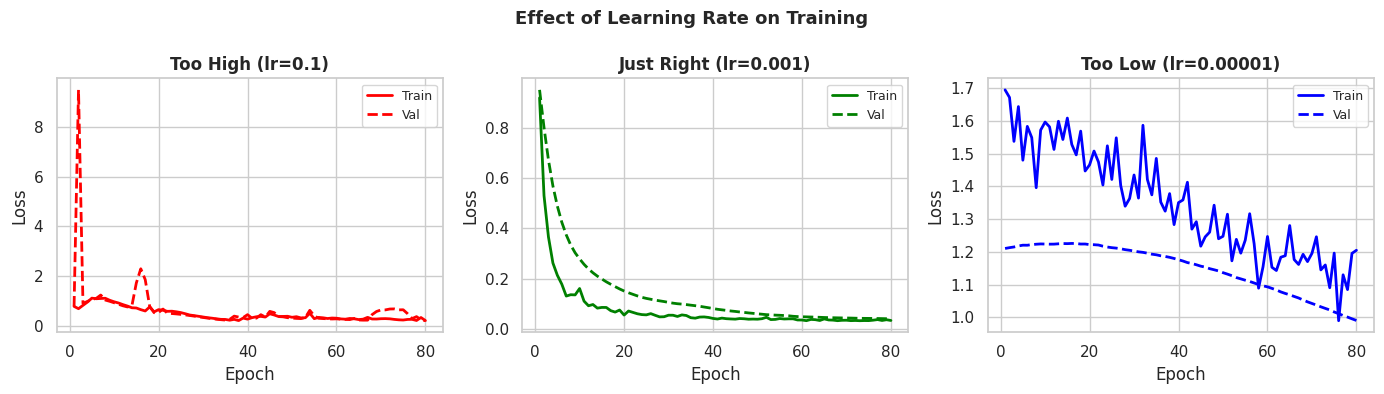

In [7]:
# Visualization: Effect of learning rate
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
lrs = [0.1, 0.001, 0.00001]
titles = ['Too High (lr=0.1)', 'Just Right (lr=0.001)', 'Too Low (lr=0.00001)']
colors = ['red', 'green', 'blue']

for ax, lr, title, color in zip(axes, lrs, titles, colors):
    m = build_mlp(INPUT_DIM, N_CLASSES, activation='relu')
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=80, batch_size=32, verbose=0)
    epochs = range(1, len(h.history['loss'])+1)
    ax.plot(epochs, h.history['loss'],     color=color, lw=2, label='Train')
    ax.plot(epochs, h.history['val_loss'], color=color, lw=2, linestyle='--', label='Val')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=9)

plt.suptitle('Effect of Learning Rate on Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/T4_learning_rate_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Experiment | Key Finding |
|---|---|
| ReLU vs Tanh | ReLU converged faster and achieved higher accuracy — mitigates vanishing gradient |
| BatchNorm + Dropout | Stable training curves, reduced overfitting gap between train/val |
| Adam optimizer | Fastest convergence, best final accuracy — adaptive learning rates help |
| SGD + momentum | Slower but comparable final accuracy with enough epochs |
| RMSProp | Between SGD and Adam in convergence speed |
| Learning rate | Critical hyperparameter — too high causes instability, too low causes slow convergence |